# Классификация: IC50 > медианы

Соединение считается активным (класс 1), если его IC50 превышает медианное значение выборки. **Примечание:** высокий IC50 означает **меньшую** эффективность, поэтому класс 1 здесь - соединения с IC50 выше медианы

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
df = pd.read_excel('/content/Данные_для_курсовои_Классическое_МО (1).xlsx', index_col=0)
FEATURE_EXCLUDE = ['IC50, mM', 'CC50, mM', 'SI']
features = [c for c in df.columns if c not in FEATURE_EXCLUDE]
X = df[features]

threshold = df['IC50, mM'].median()
y = (df['IC50, mM'] > threshold).astype(int)
print(f'Порог (IC50, mM median): {threshold:.4f}')
print(f'Баланс классов: {y.value_counts().to_dict()}')
print(f'Доля класса 1: {y.mean():.3f}')

Порог (IC50, mM median): 46.5852
Баланс классов: {0: 501, 1: 500}
Доля класса 1: 0.500


In [ ]:
X = X.fillna(0)

## 2. Разделение данных

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (800, 210), Test: (201, 210)


## 3. Обучение и сравнение моделей

In [ ]:
def evaluate_clf(name, y_true, y_pred, y_prob=None):
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    return {'Модель': name, 'F1': round(f1, 4), 'ROC-AUC': round(roc, 4)}

results = []

In [ ]:
# ── 1. Logistic Regression (baseline) ────────────────────────
lr_pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])
gs_lr = GridSearchCV(lr_pipe, {'model__C': [0.01, 0.1, 1, 10]}, cv=5, scoring='roc_auc', n_jobs=-1)
gs_lr.fit(X_train, y_train)
pred_lr = gs_lr.predict(X_test)
prob_lr = gs_lr.predict_proba(X_test)[:,1]
results.append(evaluate_clf('Logistic Regression', y_test, pred_lr, prob_lr))
print(f'LR best C: {gs_lr.best_params_}')

LR best C: {'model__C': 0.01}


In [ ]:
# ── 2. Decision Tree ──────────────────────────────────────────
gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     {'max_depth': [3, 5, 10, None], 'min_samples_leaf': [1, 5, 10]},
                     cv=5, scoring='roc_auc', n_jobs=-1)
gs_dt.fit(X_train, y_train)
pred_dt = gs_dt.predict(X_test)
prob_dt = gs_dt.predict_proba(X_test)[:,1]
results.append(evaluate_clf('Decision Tree', y_test, pred_dt, prob_dt))

In [ ]:
# ── 3. Random Forest ──────────────────────────────────────────
gs_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                     {'n_estimators': [100, 300], 'max_depth': [None, 10], 'min_samples_leaf': [1, 3]},
                     cv=5, scoring='roc_auc', n_jobs=-1)
gs_rf.fit(X_train, y_train)
pred_rf = gs_rf.predict(X_test)
prob_rf = gs_rf.predict_proba(X_test)[:,1]
results.append(evaluate_clf('Random Forest', y_test, pred_rf, prob_rf))
print(f'RF best: {gs_rf.best_params_}')

RF best: {'max_depth': 10, 'min_samples_leaf': 3, 'n_estimators': 100}


In [ ]:
# ── 4. Gradient Boosting ──────────────────────────────────────
gs_gb = GridSearchCV(GradientBoostingClassifier(random_state=42),
                     {'n_estimators': [100, 200], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]},
                     cv=5, scoring='roc_auc', n_jobs=-1)
gs_gb.fit(X_train, y_train)
pred_gb = gs_gb.predict(X_test)
prob_gb = gs_gb.predict_proba(X_test)[:,1]
results.append(evaluate_clf('Gradient Boosting', y_test, pred_gb, prob_gb))
print(f'GB best: {gs_gb.best_params_}')

GB best: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


## 4. Сравнение результатов


=== Сравнение моделей ===
             Модель     F1  ROC-AUC
      Random Forest 0.7500   0.7908
  Gradient Boosting 0.7324   0.7712
Logistic Regression 0.7042   0.7492
Logistic Regression 0.7042   0.7492
      Decision Tree 0.6852   0.7319
      Decision Tree 0.6852   0.7319


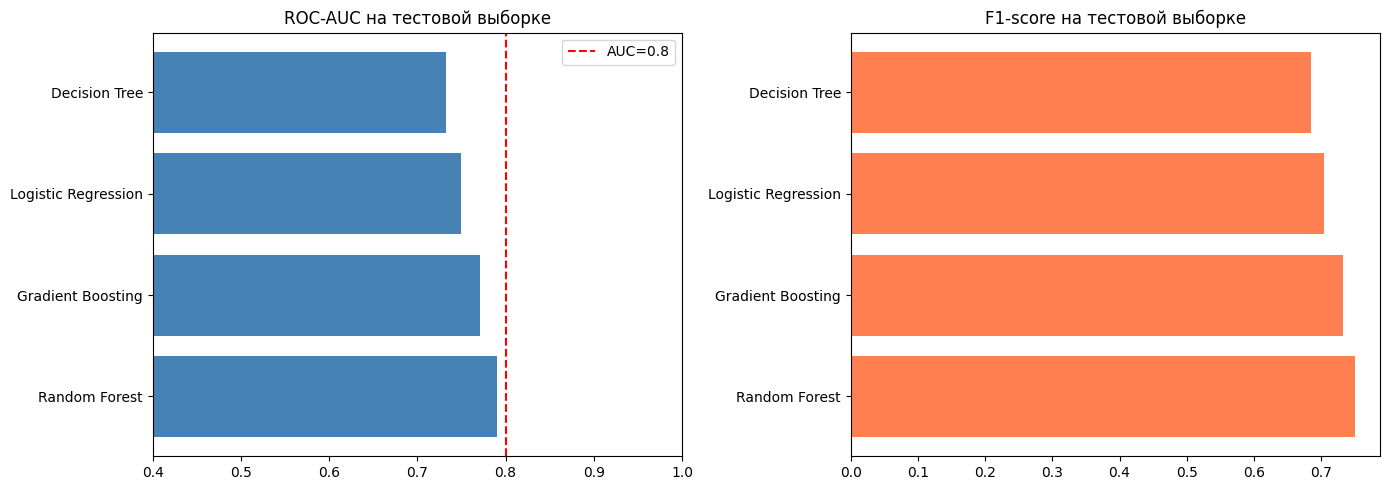

In [ ]:
results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print('\n=== Сравнение моделей ===')
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(results_df['Модель'], results_df['ROC-AUC'], color='steelblue')
axes[0].set_title('ROC-AUC на тестовой выборке')
axes[0].set_xlim(0.4, 1.0)
axes[0].axvline(0.8, color='red', linestyle='--', label='AUC=0.8')
axes[0].legend()

axes[1].barh(results_df['Модель'], results_df['F1'], color='coral')
axes[1].set_title('F1-score на тестовой выборке')
plt.tight_layout()
plt.show()

## 5. ROC-кривые

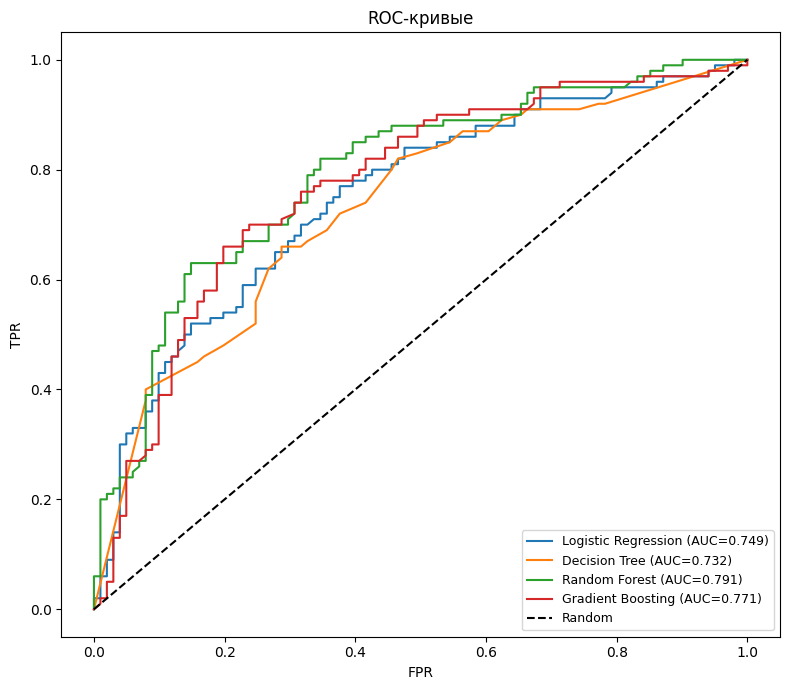

In [ ]:
# ROC-кривые всех моделей
fig, ax = plt.subplots(figsize=(8, 7))
for name, y_true, prob in [
    ('Logistic Regression', y_test, prob_lr),
    ('Decision Tree', y_test, prob_dt),
    ('Random Forest', y_test, prob_rf),
    ('Gradient Boosting', y_test, prob_gb),
]:
    fpr, tpr, _ = roc_curve(y_true, prob)
    auc = roc_auc_score(y_true, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC-кривые')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Confusion Matrix и отчёт

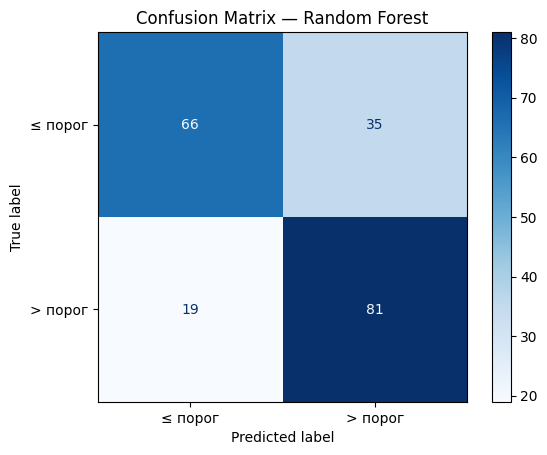

              precision    recall  f1-score   support

     ≤ порог       0.78      0.65      0.71       101
     > порог       0.70      0.81      0.75       100

    accuracy                           0.73       201
   macro avg       0.74      0.73      0.73       201
weighted avg       0.74      0.73      0.73       201



In [ ]:
# Confusion matrix лучшей модели
best_name = results_df.iloc[0]['Модель']
pred_map = {
    'Logistic Regression': pred_lr,
    'Decision Tree': pred_dt,
    'Random Forest': pred_rf,
    'Gradient Boosting': pred_gb,
}
best_pred = pred_map[best_name]
cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['≤ порог', '> порог'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()
print(classification_report(y_test, best_pred, target_names=['≤ порог', '> порог']))

## 7. Важность признаков

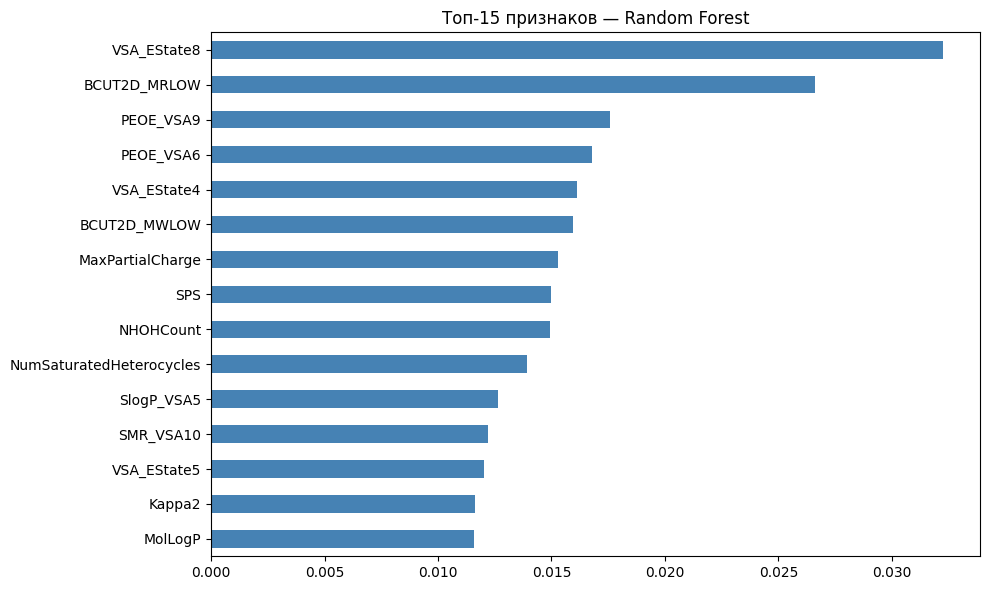

In [ ]:
# Feature importance
if 'Random Forest' in best_name:
    imp = gs_rf.best_estimator_.feature_importances_
elif 'Gradient Boosting' in best_name:
    imp = gs_gb.best_estimator_.feature_importances_
else:
    imp = None

if imp is not None:
    s = pd.Series(imp, index=features).sort_values(ascending=False).head(15)
    s[::-1].plot(kind='barh', figsize=(10,6), color='steelblue')
    plt.title(f'Топ-15 признаков — {best_name}')
    plt.tight_layout()
    plt.show()

## 8. Выводы

Вывод для файла:
"Лучшей моделью для классификации IC50 > медианы оказался Random Forest (ROC-AUC = 0.791, F1 = 0.750). Gradient Boosting показал близкий результат (ROC-AUC = 0.771, F1 = 0.732). Logistic Regression (ROC-AUC = 0.749) справилась неплохо как baseline. Decision Tree оказался слабейшим (ROC-AUC = 0.732). Ансамблевые методы превзошли линейные и древесные модели, что подтверждает нелинейный характер зависимости IC50 от молекулярных дескрипторов.